# Análisis de Brecha Salarial de Género por Macrozona - Paleta heatmap_area_opcion_a





In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurar visualización general
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)


In [4]:
# Cargar el dataset
df = pd.read_parquet('../Data/casen_2024.parquet')

# Filtro principal: Personas con ingresos en ocupación principal informados
df = df.dropna(subset=['region', 'sexo', 'yoprcor']).copy()

# Mapeo de Macrozonas
macrozona_mapping = {
    1: 'Z. Norte', 2: 'Z. Norte', 3: 'Z. Centro Norte', 4: 'Z. Centro Norte',
    5: 'Z. Centro', 6: 'Z. Centro', 7: 'Z. Centro Sur', 8: 'Z. Centro Sur',
    9: 'Z. Sur', 10: 'Z. Sur', 11: 'Z. Sur', 12: 'Z. Sur',
    13: 'Z. Centro', 14: 'Z. Sur', 15: 'Z. Norte', 16: 'Z. Centro Sur'
}
df['Macrozona'] = df['region'].map(macrozona_mapping)
macrozona_order = ['Z. Norte', 'Z. Centro Norte', 'Z. Centro', 'Z. Centro Sur', 'Z. Sur']
df['Macrozona'] = pd.Categorical(df['Macrozona'], categories=macrozona_order, ordered=True)

# Mapeo de Género
gender_mapping = {1: 'Hombre', 2: 'Mujer'}
df['Genero'] = df['sexo'].map(gender_mapping)

print(f"Total registros analizados: {len(df)}")


Total registros analizados: 92548


In [5]:
def plot_gap_heatmap(df, y_col, title, y_label, dict_map=None, invert=False, vmin=None, vmax=None):
    df_plot = df.copy()
    if dict_map:
        df_plot[y_col] = df_plot[y_col].map(dict_map)
    else:
        df_plot[y_col] = df_plot[y_col].astype(str)
        
    df_plot = df_plot.dropna(subset=[y_col])
    
    macrozona_order = ['Z. Norte', 'Z. Centro Norte', 'Z. Centro', 'Z. Centro Sur', 'Z. Sur']
    
    pivot = df_plot.pivot_table(values='yoprcor', index='Macrozona', columns=[y_col, 'Genero'], aggfunc='mean', observed=False)
    
    gap_df = pd.DataFrame(index=macrozona_order)
    for cat in pivot.columns.levels[0]:
        try:
            if 'Hombre' in pivot[cat] and 'Mujer' in pivot[cat]:
                gap_df[cat] = ((pivot[cat]['Hombre'] - pivot[cat]['Mujer']) / pivot[cat]['Hombre']) * 100
        except KeyError:
            continue
            
    gap_df = gap_df.dropna(how='all', axis=1)
    
    if invert:
        gap_df = gap_df.T
        plt.figure(figsize=(10, 8))
        sns.heatmap(gap_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=vmin, vmax=vmax, cbar_kws={'label': 'Brecha (%)'})
        plt.xlabel('Macro-Zona')
        plt.ylabel(y_label)
    else:
        plt.figure(figsize=(12, 6))
        sns.heatmap(gap_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=vmin, vmax=vmax, cbar_kws={'label': 'Brecha (%)'})
        plt.ylabel('Macro-Zona')
        plt.xlabel(y_label)
        plt.xticks(rotation=45, ha='right')
        
    plt.title(f'Brecha Salarial por Macrozona y {title}')
    plt.tight_layout()
    plt.show()


## 3. Quintil de Ingresos

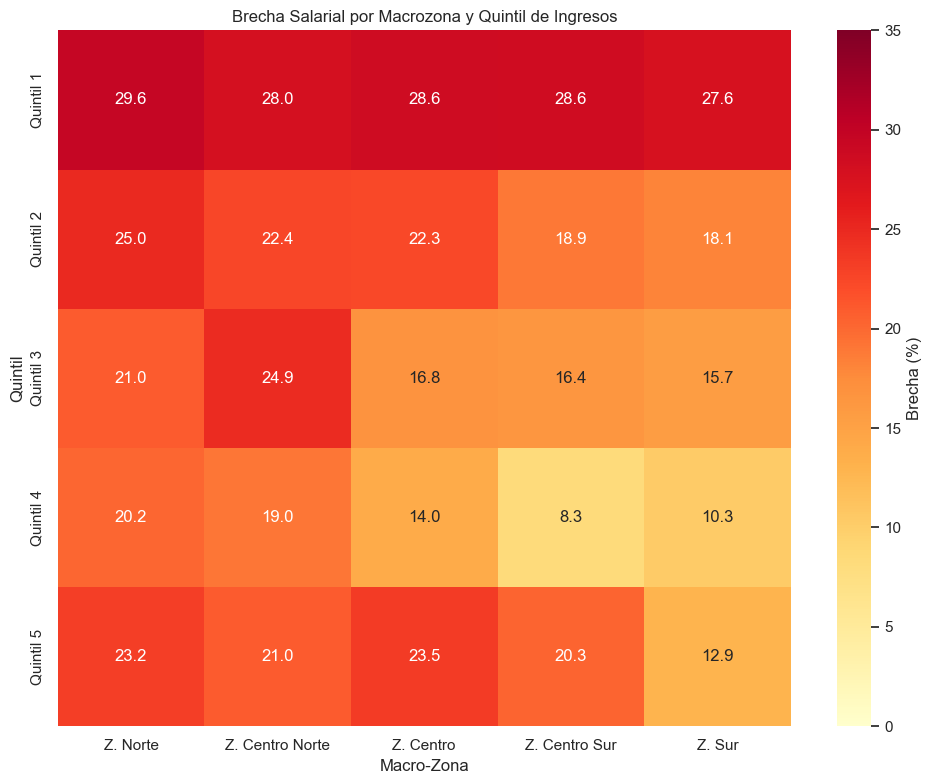

In [6]:
# Ajusta vmin y vmax para cambiar la escala de colores
min_escala = 10
max_escala = 35

map_qaut = {1: 'Quintil 1', 2: 'Quintil 2', 3: 'Quintil 3', 4: 'Quintil 4', 5: 'Quintil 5'}
plot_gap_heatmap(df, 'qaut', 'Quintil de Ingresos', 'Quintil', 
                 dict_map=map_qaut, invert=True, vmin = 0, vmax = 35)